# Past-aware game-theoretic centrality: a framework for cardinality-constrained set-function maximization on networks
## *Facility location*

In [1]:
import networkx as nx
import numpy as np
import math
import osmnx as ox
import matplotlib.pyplot as plt
import itertools
import osmnx as ox

## PAGTC scores

For a general group centrality $f$ and probability distribution $\beta:\{0,\dots,n-1\}\to[0,1]$, the $\beta$-semivalue PAGTC is defined as
$$
\phi^\beta_f (u|P)=C_\beta\cdot\sum_{s=|P|}^{n-1}\dfrac{\beta(s)}{\binom{n-1}{s}}\sum_{\substack{S\subseteq V\setminus\{u\}\\|S|=s,\,S\supseteq P}}f (u|S)
$$
where $C_\beta$ is a normalization constant that does not depend on $u$:
$$
C_\beta=\left(\sum_{s=|P|}^{n-1}\beta(s)\dfrac{\binom{n-1-|P|}{s-|P|}}{\binom{n-1}{s}}\right)^{\!\!-1}.
$$

In [2]:
def beta_shapley(n, s):
    return 1/n

def beta_delta(r):
    return lambda n, s: 1 if s == r else 0

def binom(n, k):
    return 0 if k < 0 or n < 0 else math.comb(n,k)

def c_beta(beta, n, S0):
    inverse_c_beta = 0.0    
    for s in range(len(S0), n):
        inverse_c_beta += beta(n, s) * (binom(n - 1 - len(S0), s - len(S0)) / binom(n - 1, s))
    return 1 / inverse_c_beta

# For testing only
def general_pagtc(G, group_centrality, beta, S0=[], nodes=None): 
    V = set(G.nodes())
    n = len(V)
    S0 = set(S0)
    s0 = len(S0)

    c_beta_value = c_beta(beta, n, S0)

    nodes = set(G.nodes) if nodes == None else set(nodes)
    centrality = {u: 0 for u in nodes}

    for u in nodes - S0:
        for s in range(s0, n):
            for subset in itertools.combinations(V - {u}, s):
                S = set(subset)
                if S0.issubset(S):
                    marginal_contribution = group_centrality(G, S.union({u})) - group_centrality(G, S)
                    centrality[u] += c_beta_value * beta(n, s) / binom(n - 1, s) * marginal_contribution
    return centrality

def rho_covering(D):
    return lambda d: 1 if d <= D else 0

def rho_harmonic(d):
    return 0 if d==0 else 1/d

def distance_group_centrality(G, rho, S):
    if len(S) == 0:
        return 0
    dist = dict(nx.all_pairs_shortest_path_length(G))
    return sum(rho(min(dist[s][v] for s in S)) for v in G.nodes())

### Semivalue PAGTC
Given a graph $G=(V,E)$, the $\beta$-semivalue PAGTC with $\beta=\delta_s$ associated with the group centrality
$$
f_\rho(S)=\begin{cases}
    \displaystyle\sum_{v \in V}\rho\bigl(d(S,v)\bigr) & \text{if $S\ne\varnothing$}\\[.5ex]
    0 & \text{if $S=\varnothing$},
\end{cases}
$$
can be computed as
$$
\phi_{f_\rho}^{\delta_{s}}(u|P) = \sum_{v\notin P} \sum_{l=d_{uv}}^{d(P, v)-1} \Delta\rho(l)\frac{\binom{m^>(v,l)-|P|}{s-|P|}}{\binom{n-1-|P|}{s-|P|}}
$$
where $m^>(v,l)$ denotes the number of nodes $w\in V$ such that $d_{vw}>l$ and $\Delta\rho(l)=\rho(l)-\rho(l+1)$.

In [3]:
def distance_pagtc_delta(G, rho, s, S0=[], nodes=None, precomputed_dist=None):
    V = set(G.nodes())
    n = len(V)
    S0 = set(S0)
    s0 = len(S0)
    
    nodes = set(G.nodes()) if nodes is None else set(nodes)
    centrality = {u: 0.0 for u in nodes}

    if precomputed_dist==None:
        dist = dict(nx.all_pairs_shortest_path_length(G))
    else:
        dist = precomputed_dist
    diam = max(max(d.values()) for d in dist.values())

    def zerho(d):
        return 0 if d > diam else rho(d)

    delta_rho = [zerho(d) - zerho(d+1) for d in range(diam + 1)]

    m = {v: {d: 0 for d in range(diam + 1)} for v in V}
    for v in V:
        counts = {d: 0 for d in range(diam + 1)}
        for w in V:
            counts[dist[w][v]] += 1
            
        current_sum = 0
        for d in range(diam, -1, -1):
            m[v][d] = current_sum
            current_sum += counts[d]

    denominator = binom(n - 1 - s0, s - s0)    
    suffix_sums = {v: [0.0] * (diam + 2) for v in V - S0}
    for v in V - S0:
        limit_v = diam + 1 if s0 == 0 else min(dist[s_node][v] for s_node in S0)        
        current_sum = 0.0
        for d in range(limit_v - 1, -1, -1):
            numerator = binom(m[v][d] - s0, s - s0)
            term = delta_rho[d] * (numerator / denominator)
            
            current_sum += term
            suffix_sums[v][d] = current_sum

    for u in nodes - S0:
        for v in V - S0:
            d_uv = dist[u][v]
            centrality[u] += suffix_sums[v][d_uv]
            
    return centrality

### Shapley PAGTC
The corresponding Shapley value, i.e., when $\beta$ is uniformly distributed, can be computed as follows:
$$
\phi_{f_\rho}^{\mathrm{Sh}}(u|P)=\sum_{v\notin P} \sum_{l=d_{uv}}^{d(P, v)-1} \frac{\Delta\rho(l)}{\binom{m^\le(v,l)+|P|}{|P|+1}}
$$
where $m^\le(v,l)$ denotes the number of nodes $w\in V$ such that $d_{vw}\le l$.

In [4]:
def distance_pagtc_shapley(G, rho, S0=[], nodes=None, precomputed_dist=None):
    V = set(G.nodes())
    n = len(V)
    S0 = set(S0)
    s0 = len(S0)
    
    nodes = set(G.nodes()) if nodes is None else set(nodes)
    centrality = {u: 0 for u in nodes}

    if precomputed_dist==None:
        dist = dict(nx.all_pairs_shortest_path_length(G))
    else:
        dist = precomputed_dist
    diam = max(max(d.values()) for d in dist.values())

    def zerho(d):
        return 0 if d > diam else rho(d)

    m = {v: {d: 0 for d in range(diam+1)} for v in V}
    for v in V:
        counts = {d: 0 for d in range(diam+1)}
        for w in V:
            counts[dist[w][v]] += 1
        current_sum = 0
        for d in range(diam, -1, -1):
            m[v][d] = current_sum
            current_sum += counts[d]

    for u in nodes - S0:
        for v in V - S0:
            limit = diam + 1 if s0 == 0 else min(dist[w][v] for w in S0)
            for d in range(dist[u][v], limit):
                centrality[u] += (zerho(d)-zerho(d+1)) / (binom(n-m[v][d]+s0, s0+1))
                
    return centrality

### Test

Testing the implementation of the closed-form expressions for the specific distance-based PAGTC $\phi_{f_\rho}$ against the general (slow) PAGTC expression.

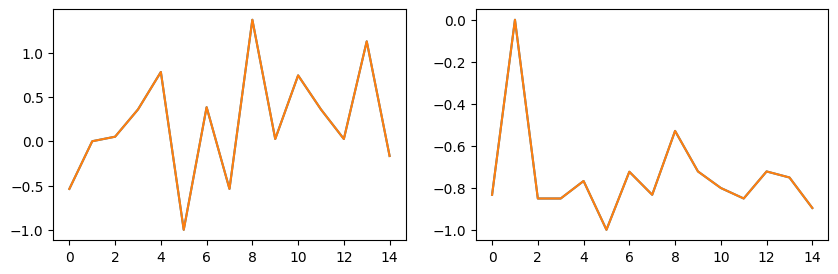

In [5]:
G = nx.florentine_families_graph()

harmonic_group_centrality = lambda G, S: distance_group_centrality(G, rho_harmonic, S)
S0 = ['Albizzi']
precomputed_dist = dict(nx.all_pairs_shortest_path_length(G))

fig, ax = plt.subplots(1, 2, figsize=(10, 3))

c1 = distance_pagtc_delta(G, rho_harmonic, 2, S0=S0, precomputed_dist=precomputed_dist)
c2 = general_pagtc(G, harmonic_group_centrality, beta_delta(2), S0=S0, nodes=None)
c1 = dict(sorted(c1.items(), key=lambda x: x[0]))
c2 = dict(sorted(c2.items(), key=lambda x: x[0]))
ax[0].plot(c1.values())
ax[0].plot(c2.values())

c1 = distance_pagtc_shapley(G, rho_harmonic, S0=S0)
c2 = general_pagtc(G, harmonic_group_centrality, beta_shapley, S0=S0, nodes=None)
c1 = dict(sorted(c1.items(), key=lambda x: x[0]))
c2 = dict(sorted(c2.items(), key=lambda x: x[0]))
ax[1].plot(c1.values())
ax[1].plot(c2.values())
pass

## PAGTC for set-function maximization

### Greedy strategy (baseline)

We construct the solution $S_r$ iteratively:
$$
\begin{cases}
S_0 = \varnothing\\
S_k = S_{k-1} \cup \{u_k\}
\end{cases}
$$
where
$$
u_k \in \mathrm{argmax}_{u\notin S_{k-1}}f(u|S_{k-1}) = \phi^{\delta_{|S_{k-1}|}}_f(u|S_{k-1})
$$

In the submodular case, the corresponding _a posteriori_ bound is
$$
f(S^*) \le \min_{1 \le k \le r} \left( f(S_{k-1}) + \sum_{i=1}^r f\left(v_i^{(k)}\Big|S_{k-1}\right) \right)
$$
where $v_1^{(k)},\dots,v_r^{(k)}$ are the nodes in $V\setminus S_{k-1}$ yielding the $r$ largest marginal contributions to $S_{k-1}$.

In [6]:
def construct_greedy_solution(G, rho, r, compute_bounds=False):
    precomputed_dist = dict(nx.all_pairs_shortest_path_length(G))
    S = []
    if compute_bounds:
        bound, p = {}, {}
    k = 0
    while len(S) < r:
        k += 1
        # Here S = S_{k-1}
        centrality = distance_pagtc_delta(G, rho, len(S), S0=S, precomputed_dist=precomputed_dist, nodes = set(G.nodes) - set(S)) # equivalent to greedy
        uk = max(centrality, key=centrality.get)
        S.append(uk)
        if compute_bounds:
            p[k] = centrality[uk]
            bound[k] = sum(sorted(centrality.values(), reverse=True)[:r])

    if compute_bounds:
        fS = distance_group_centrality(G, rho, set(S))
        fSk = {}
        fSk[r] = fS
        bound[r] += fS - p[r]
        for k in range(r-1,0,-1):
            fSk[k] = fSk[k+1]-p[k+1]
            bound[k] += fSk[k]-p[k]
        return S, fS, bound
    else:
        return S

### PAGTC strategy

We construct the solution $S_r$ iteratively:
$$
\begin{cases}
S_0 = \varnothing\\
S_k = S_{k-1} \cup \{u_k\}
\end{cases}
$$
where
$$
u_k \in \mathrm{argmax}_{u\notin S_{k-1}}\phi^{\delta_{r-1}}_f(u|S_{k-1})
$$

In the submodular case, the corresponding _a posteriori_ bound is
$$
f(S^*)\le\min_{1 \le k \le r} \left( \mathbb E\bigl[f(T_k)\bigr]+\alpha_k\sum_{i=1}^r \phi_f^{\delta_{r-1}}\left(v_{i}^{(k)}\Big|S_{k-1}\right)\right)
$$
where $\alpha_k=\frac{n-r+1}{n-k+1}$ and $v_1^{(k)},\dots,v_r^{(k)}$ are the nodes in $V\setminus S_{k-1}$ yielding the $r$ largest values of the PAGTC metric $\phi_f^{\delta_{r-1}}(\,\cdot\,|S_{k-1})$.

We have that $\mathbb E\bigl[f(T_k)\bigr]$ satisfies
$$
\mathbb E\bigl[f(T_k)\bigr] = \underbrace{\mathbb E\bigl[f(T_r)\bigr]}_{=f(S_{r-1})}+\sum_{i=k}^{r-1}\alpha_{i}(q_i-p_i)
$$
where
$$
p_k=\phi^{\delta_{r-1}}_f(u_k|S_{k-1}), \qquad
q_k=\dfrac{1}{n-k}\sum_{u\notin S_k}\phi^{\delta_{r-1}}_f(u|S_k).
$$

In [7]:
def construct_pagtc_solution(G, rho, r, compute_bounds=False):
    precomputed_dist = dict(nx.all_pairs_shortest_path_length(G))
    n = len(G)
    S = []
    if compute_bounds:
        bound, p, q = {}, {}, {}
    k = 0
    while len(S) < r:
        k += 1
        # Here S = S_{k-1}
        centrality = distance_pagtc_delta(G, rho, r-1, S0=S, precomputed_dist=precomputed_dist, nodes = set(G.nodes) - set(S))
        uk = max(centrality, key=centrality.get)
        S.append(uk)
        if compute_bounds:
            p[k] = centrality[uk]
            bound[k] = (n-r-1)/(n-k-1) * sum(sorted(centrality.values(), reverse=True)[:r])
            q[k-1] = 1/(n-k+1) * sum(centrality.values())

    if compute_bounds:
        fS = distance_group_centrality(G, rho, set(S))
        EfTk = {}
        EfTk[r] = fS - p[r]
        bound[r] += EfTk[r]
        for k in range(r-1,0,-1):
            EfTk[k] = EfTk[k+1] + (n-r-1)/(n-k-1) * (q[k]-p[k])
            bound[k] += EfTk[k]    
        return S, fS, bound
    else:
        return S

## Experiments

In [8]:
import random
def random_reordering(G, N):
    reorderings = []
    edges = list(G.edges(data=True))
    nodes = list(G.nodes(data=True))
    for _ in range(N):
        G_ = G.__class__()
        G_.add_nodes_from(random.sample(nodes, len(G))) 
        G_.add_edges_from(edges)
        reorderings.append(G_)
    return reorderings

### Code for Figure 2

In [9]:
def square_grid_with_diagonal_neighbors(n):
    G = nx.grid_2d_graph(n, n)
    def add_diagonal(G, u, v, dx, dy):
        if (u+dx, v+dy) in G:
            G.add_edge((u,v), ((u+dx, v+dy) ))
    for (u,v) in G:
        add_diagonal(G, u,v, 1,1)
        add_diagonal(G, u,v, 1,-1)
        add_diagonal(G, u,v, -1,1)
        add_diagonal(G, u,v, -1,-1)
    return G

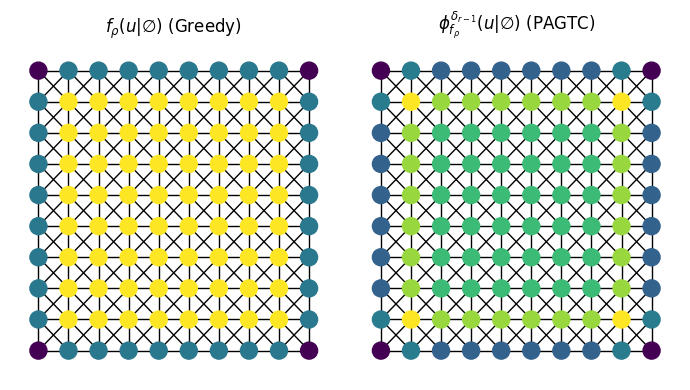

In [10]:
G = square_grid_with_diagonal_neighbors(10)
pos = {u: u for u in G}

rho = rho_covering(1)
r = 9

fig, ax = plt.subplots(1, 2, figsize=(7, 4))
# fig.suptitle(r'Maximum coverage problem with radius $R=1$ and budget $r=9$')

influenced = []

node_color =  dict(sorted(distance_pagtc_delta(G, rho, len(influenced), S0=influenced).items())).values()
nx.draw(G, ax=ax[0], pos=pos, node_color=node_color, with_labels=False, cmap='viridis', node_size=150)
ax[0].set_title(r'$f_\rho(u|\varnothing)$ (Greedy)')

node_color =  dict(sorted(distance_pagtc_delta(G, rho, r-1, S0=influenced).items())).values()
nx.draw(G, ax=ax[1], pos=pos, node_color=node_color, with_labels=False, cmap='viridis', node_size=150)
ax[1].set_title(r'$\phi_{f_\rho}^{\delta_{r-1}}(u|\varnothing)$ (PAGTC)')
plt.tight_layout()


### Code for Table 1

In [11]:
np.random.seed(42)
radius = 2
m = 2
r = m**2
G_ = square_grid_with_diagonal_neighbors((2*radius+1) * m)
n = len(G_)
rho = rho_covering(radius)

N = 10
pagtc_score, greedy_score = 0, 0
for G in random_reordering(G_, N):

    pagtc_solution = construct_pagtc_solution(G, rho, r)
    pagtc_score += 1/N *(distance_group_centrality(G, rho, set(pagtc_solution)))

    greedy_solution = construct_greedy_solution(G, rho, r)
    greedy_score += 1/N *(distance_group_centrality(G, rho, set(greedy_solution)))

print(f'|V|={n},\t r={r}\t radius={radius}\t Greedy: {100*greedy_score/n:.1f}%\t PAGTC: {100*pagtc_score/n:.1f}')

|V|=100,	 r=4	 radius=2	 Greedy: 95.0%	 PAGTC: 100.0


### Code for Figure 3

Graph with 1928 nodes and 2686 edges.


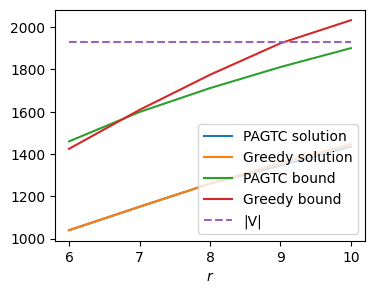

In [12]:
street_map = ox.graph_from_point((43.715049, 10.396794), dist=2500, network_type="drive")
gdf_nodes, gdf_edges = ox.graph_to_gdfs(street_map)
street_map = ox.graph_from_gdfs(gdf_nodes, gdf_edges)
street_map.remove_edges_from(nx.selfloop_edges(street_map))
street_map = street_map.to_undirected()

G = street_map
n = len(G)
print(f'Graph with {len(G.nodes)} nodes and {len(G.edges)} edges.')

radius = 9
rho = rho_covering(radius)

lenG = {}
fSg, fSp = {}, {}
boundg, boundp = {}, {}
for r in range(6,11):
    lenG[r] = n

    Sp, fSp[r], bound = construct_pagtc_solution(G, rho, r, compute_bounds=True)
    boundp[r] = min(bound.values())

    Sg, fSg[r], bound = construct_greedy_solution(G, rho, r, compute_bounds=True)
    boundg[r] = min(bound.values())

plt.figure(figsize=(4,3))
plt.plot(*zip(*fSp.items()), label='PAGTC solution')
plt.plot(*zip(*fSg.items()), label='Greedy solution')
plt.plot(*zip(*boundp.items()), label='PAGTC bound')
plt.plot(*zip(*boundg.items()), label='Greedy bound')
plt.plot(*zip(*lenG.items()), linestyle='dashed', label='|V|')
plt.xlabel(r'$r$')
plt.legend()
pass


Graph with 1928 nodes and 2686 edges.
PAGTC2: solution=1260, bound=1711.8284379878219
greedy: solution=1260, bound=1775.0
Sp \ Sg = set()


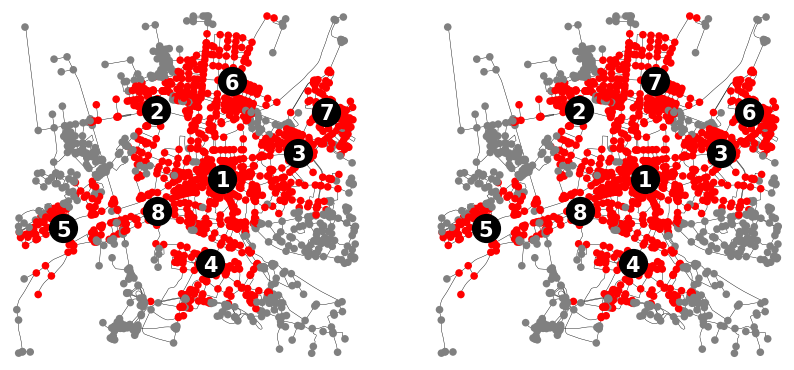

In [13]:
G = street_map
n = len(G)
print(f'Graph with {len(G.nodes)} nodes and {len(G.edges)} edges.')
dist = dict(nx.all_pairs_shortest_path_length(G))

radius = 9
r = 8
rho = rho_covering(radius)

Sp, fS, bound = construct_pagtc_solution(G, rho, r, compute_bounds=True)
print(f'PAGTC2: solution={fS}, bound={min(bound.values())}')

Sg, fS, bound = construct_greedy_solution(G, rho, r,  compute_bounds=True)
print(f'greedy: solution={fS}, bound={min(bound.values())}')
fSg[r] = fS

print(f'Sp \\ Sg = {set(Sp)-set(Sg)}')
        
def choose_color(u, solution):
    return 'red' if min([dist[u][v] for v in solution]) <= radius else 'gray'

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for i, solution in enumerate([Sg, Sp]):

    ox.plot_graph(street_map,
        ax = ax[i], show=False, bgcolor="w",
        node_color=[choose_color(u, solution) for u in G],
        node_size=30, edge_color='k', edge_linewidth = .3)

    for k, u in enumerate(solution):
        if u in G.nodes:
            x = G.nodes[u]['x']
            y = G.nodes[u]['y']
            ax[i].plot(x, y, 'ko', markersize=20)
            ax[i].text(x, y, s=rf'$\mathbf{{{k+1}}}$', color='white', fontsize=15, fontweight='bold', ha='center', va='center_baseline')